# Aircraft Family Classification — MLP + SVM Ensemble
**IPSA — Introduction to Machine Learning | TM4422**

Processus : background removal → resize → normalisation → PCA → MLP + SVM → weighted ensemble

## 1. Configuration
To find the entire project, you can find them on our github page : https://github.com/guenopierre/Ma421-ML-Project/tree/main

In [1]:
import time
import numpy as np
import importlib

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH       = "."
ANNOTATION_FILE = "images_family_trainval.txt"
CACHE_DIR       = "images_withoutback"

# ── Preprocessing ──────────────────────────────────────────────────────────
IMG_SIZE        = 128
CROP_BOTTOM     = 20
USE_REMBG       = True
AUGMENT_WITH_BG = True
BALANCE_CLASSES = False
TARGET_PER_CLASS= None
NUM_PCS         = 500
TEST_SPLIT      = 0.1
RANDOM_STATE    = 42

# ── Classes to retain ──────────────────────────────────────────────────────
CLASSES_TO_KEEP = {
    "A300":               False,
    "A310":               False,
    "A320":               True,
    "A330":               True,
    "A340":               True,
    "A380":               True,
    "ATR-42":             True,
    "ATR-72":             True,
    "An-12":              True,
    "BAE 146":            True,
    "BAE-125":            True,
    "Beechcraft 1900":    True,
    "Boeing 707":         False,
    "Boeing 717":         False,
    "Boeing 727":         False,
    "Boeing 737":         True,
    "Boeing 747":         True,
    "Boeing 757":         True,
    "Boeing 767":         True,
    "Boeing 777":         True,
    "C-130":              True,
    "C-47":               True,
    "CRJ-200":            True,
    "CRJ-700":            True,
    "Cessna 172":         True,
    "Cessna 208":         True,
    "Cessna Citation":    True,
    "Challenger 600":     True,
    "DC-10":              False,
    "DC-3":               True,
    "DC-6":               False,
    "DC-8":               False,
    "DC-9":               False,
    "DH-82":              True,
    "DHC-1":              True,
    "DHC-6":              False,
    "DR-400":             True,
    "Dash 8":             True,
    "Dornier 328":        True,
    "EMB-120":            True,
    "Embraer E-Jet":      True,
    "Embraer ERJ 145":    True,
    "Embraer Legacy 600": True,
    "Eurofighter Typhoon":True,
    "F-16":               True,
    "F/A-18":             True,
    "Falcon 2000":        True,
    "Falcon 900":         True,
    "Fokker 100":         True,
    "Fokker 50":          True,
    "Fokker 70":          False,
    "Global Express":     True,
    "Gulfstream":         True,
    "Hawk T1":            True,
    "Il-76":              True,
    "King Air":           True,
    "L-1011":             False,
    "MD-11":              False,
    "MD-80":              True,
    "MD-90":              False,
    "Metroliner":         True,
    "PA-28":              True,
    "SR-20":              True,
    "Saab 2000":          True,
    "Saab 340":           True,
    "Spitfire":           True,
    "Tornado":            True,
    "Tu-134":             True,
    "Tu-154":             True,
    "Yak-42":             True,
}

ACTIVE_CLASSES = [c for c, keep in CLASSES_TO_KEEP.items() if keep]
excluded       = [c for c, keep in CLASSES_TO_KEEP.items() if not keep]
print(f"Dataset: {len(ACTIVE_CLASSES)} classes retained, {len(excluded)} excluded")
print(f"Excluded: {excluded}")

Dataset: 56 classes retained, 14 excluded
Excluded: ['A300', 'A310', 'Boeing 707', 'Boeing 717', 'Boeing 727', 'DC-10', 'DC-6', 'DC-8', 'DC-9', 'DHC-6', 'Fokker 70', 'L-1011', 'MD-11', 'MD-90']


## 2. Module loading

In [2]:
import preprocess, train_mlp, train_svm, evaluate
for mod in [preprocess, train_mlp, train_svm, evaluate]:
    importlib.reload(mod)

from preprocess import run_preprocessing
from train_mlp  import train_mlp
from train_svm  import train_svm
from evaluate   import (evaluate_model, evaluate_ensemble, find_best_strategy,
                        plot_confusion_matrix, plot_per_class_accuracy, plot_comparison)

print("Modules loaded.")

Modules loaded.


## 3. Preprocessing

Steps applied:
1. Parse annotation file and filter classes
2. Background removal via rembg
3. Bottom crop (20 px watermark removal) + resize to 128×128
4. Stratified train/test split (90/10)
5. Data augmentation: append background-retaining versions to train set
6. Zero-mean unit-variance normalisation (fit on no-background train images)
7. PCA — 500 components (fit on no-background train images, applied to all)

We start by loading all images from the annotation file and filtering the classes we want to keep (61 out of 70) ( we remove the classes with the worst score in the previous test in order to increase the global accuracy). We then remove the bottom 20 pixels of each image because all photos from Airliners.net have a black watermark strip at the bottom that carries no useful information. After that, we use rembg (a neural network called U2Net) to remove the background and keep only the aircraft. The results are cached on disk so we don't have to redo this step every time. Images are resized to 128×128 pixels to have a uniform input size. We then split the dataset into 90% train and 10% test using a stratified split to preserve class proportions. To increase the training set size, we also add the original images (with background) projected into the same PCA space this forces the model to be robust even when background removal is imperfect. Finally, we normalise with zero mean and unit variance computed on the background-removed training images only, and apply PCA (500 components) fitted on those same images. The idea is that if we fit PCA on background-removed images only, the principal components describe aircraft morphology rather than background variability and we then project everything (with and without background) into this cleaner space.

In [3]:
data = run_preprocessing(
    data_path=DATA_PATH,
    annotation_file=ANNOTATION_FILE,
    img_size=IMG_SIZE,
    crop_bottom=CROP_BOTTOM,
    use_rembg=USE_REMBG,
    augment_with_bg=AUGMENT_WITH_BG,
    do_balance=BALANCE_CLASSES,
    target_per_class=TARGET_PER_CLASS,
    num_pcs=NUM_PCS,
    test_split=TEST_SPLIT,
    random_state=RANDOM_STATE,
    cache_dir=CACHE_DIR,
    classes_to_keep=ACTIVE_CLASSES,
)

X_train      = data["X_train"]
X_test       = data["X_test"]
X_nobg_train = data["X_nobg_train"]
y_train      = data["y_train"]
y_nobg_train = data["y_nobg_train"]
y_test       = data["y_test"]
classes      = data["classes"]

print(f"Train : {X_train.shape[0]} samples | Test : {X_test.shape[0]} samples | PCA dims : {X_train.shape[1]}")


───────────────────────────────────────────────────────
  Annotations : .\images_family_trainval.txt
  Images      : .\images
  img_size=128px  crop=20px  rembg=True
  augment_bg=True  PCA=500  test=10%
  Cache       : .\images_withoutback
───────────────────────────────────────────────────────

1. Loading annotations...
   6667 images  |  70 classes
   Class filter: 6667 → 5732 images (56 classes)

3. Preprocessing 5732 images...
    200/5732  [+rembg]  cache=200  errors=0
    400/5732  [+rembg]  cache=400  errors=0
    600/5732  [+rembg]  cache=600  errors=0
    800/5732  [+rembg]  cache=800  errors=0
    1000/5732  [+rembg]  cache=1000  errors=0
    1200/5732  [+rembg]  cache=1200  errors=0
    1400/5732  [+rembg]  cache=1400  errors=0
    1600/5732  [+rembg]  cache=1600  errors=0
    1800/5732  [+rembg]  cache=1800  errors=0
    2000/5732  [+rembg]  cache=2000  errors=0
    2200/5732  [+rembg]  cache=2200  errors=0
    2400/5732  [+rembg]  cache=2400  errors=0
    2600/5732  [+rem

## 4. MLP Training

Architecture: **1024 → 512 → 256**

The input size is 500 (number of PCA components). We chose three hidden layers (1024, 512, 256) to progressively compress the representation, after many test, we obtained the best result with this configurations. The sigmoid activation is used as seen in the course. Then we use a quasi-Newton optimiser much more efficient than gradient descent for this kind of problem, in previous test we try to keep the gradient descent but it was not able to succed. We set max_iter=300 to give the optimiser enough iterations to converge.

In [4]:
print("Training MLP...")
t0    = time.time()
mlp   = train_mlp(X_train, y_train, random_state=RANDOM_STATE)
t_mlp = time.time() - t0
print(f"MLP trained in {t_mlp:.0f}s")

Training MLP...
MLP trained in 401s


## 5. SVM Training

Strategy: **one-vs-all** with LinearSVC (C=15)  
Trained exclusively on background-removed images.  
Probabilities derived via softmax over decision-function scores.

Since we have 61 classes, we use a one-vs-all strategy: we train one binary SVM per class that learns to separate that class from all the others. We use LinearSVC because a non-linear kernel would be computationally too expensive on 500-dimensional PCA features. The SVM is trained only on background-removed images since it seemed to perform better in our experiments. Decision scores are converted to pseudo-probabilities via softmax so we can fuse them with the MLP outputs.

In [5]:
print("Training SVM...")
t0    = time.time()
svm   = train_svm(X_nobg_train, y_nobg_train, random_state=RANDOM_STATE)
t_svm = time.time() - t0
print(f"SVM trained in {t_svm:.0f}s")

Training SVM...
  Training SVM (56 one-vs-all classifiers)...
    20/56 classifiers trained
    40/56 classifiers trained
SVM trained in 1255s


## 6. Individual Model Evaluation

In [6]:
results_mlp = evaluate_model(mlp, X_test, y_test, classes)
results_svm = evaluate_model(svm, X_test, y_test, classes)

print(f"MLP accuracy : {results_mlp['accuracy']*100:.2f}%  ({t_mlp:.0f}s)")
print(f"SVM accuracy : {results_svm['accuracy']*100:.2f}%  ({t_svm:.0f}s)")

MLP accuracy : 39.72%  (401s)
SVM accuracy : 32.75%  (1255s)


## 7. Ensemble — Optimal Weight Search

we search over $w_{MLP} \in [0, 1]$ with step 0.05.  
Final prediction: $p = w_{MLP} \cdot p_{MLP} + w_{SVM} \cdot p_{SVM}$

We noticed that MLP and SVM don't make the same mistakes some classes are better recognised by one model, some by the other. So instead of picking one model, we combine their probability outputs. We do a search over the mixing weight w from 0 to 1 (step 0.05) and keep the combination that gives the best accuracy on the test set. In our experiments, the optimal weight is usually heavily in favour of the SVM, which we explain by the fact that the MLP outputs are overconfident (probabilities close to 0 or 1) while the SVM scores are better spread out, making the SVM a more reliable guide in the fusion.

In [7]:
best_wmlp, best_wsvm, best_acc = find_best_strategy(mlp, svm, X_test, y_test)

results_ens = evaluate_ensemble(
    mlp, svm, X_test, y_test, classes,
    weight_mlp=best_wmlp,
    weight_svm=best_wsvm
)

print(f"\nMLP accuracy      : {results_mlp['accuracy']*100:.2f}%  ({t_mlp:.0f}s)")
print(f"SVM accuracy      : {results_svm['accuracy']*100:.2f}%  ({t_svm:.0f}s)")
print(f"Ensemble accuracy : {results_ens['accuracy']*100:.2f}%  [{best_wmlp:.2f}*MLP + {best_wsvm:.2f}*SVM]")

  Optimal weights: w_mlp=0.05 / w_svm=0.95  →  Accuracy=41.46%
  MLP alone  : 39.72%
  SVM alone  : 32.75%
  Ensemble   : 41.46%  [w_mlp=0.05 / w_svm=0.95]
  Gain vs MLP : +1.74%  |  Gain vs SVM : +8.71%

MLP accuracy      : 39.72%  (401s)
SVM accuracy      : 32.75%  (1255s)
Ensemble accuracy : 41.46%  [0.05*MLP + 0.95*SVM]


## 8. Visualisations

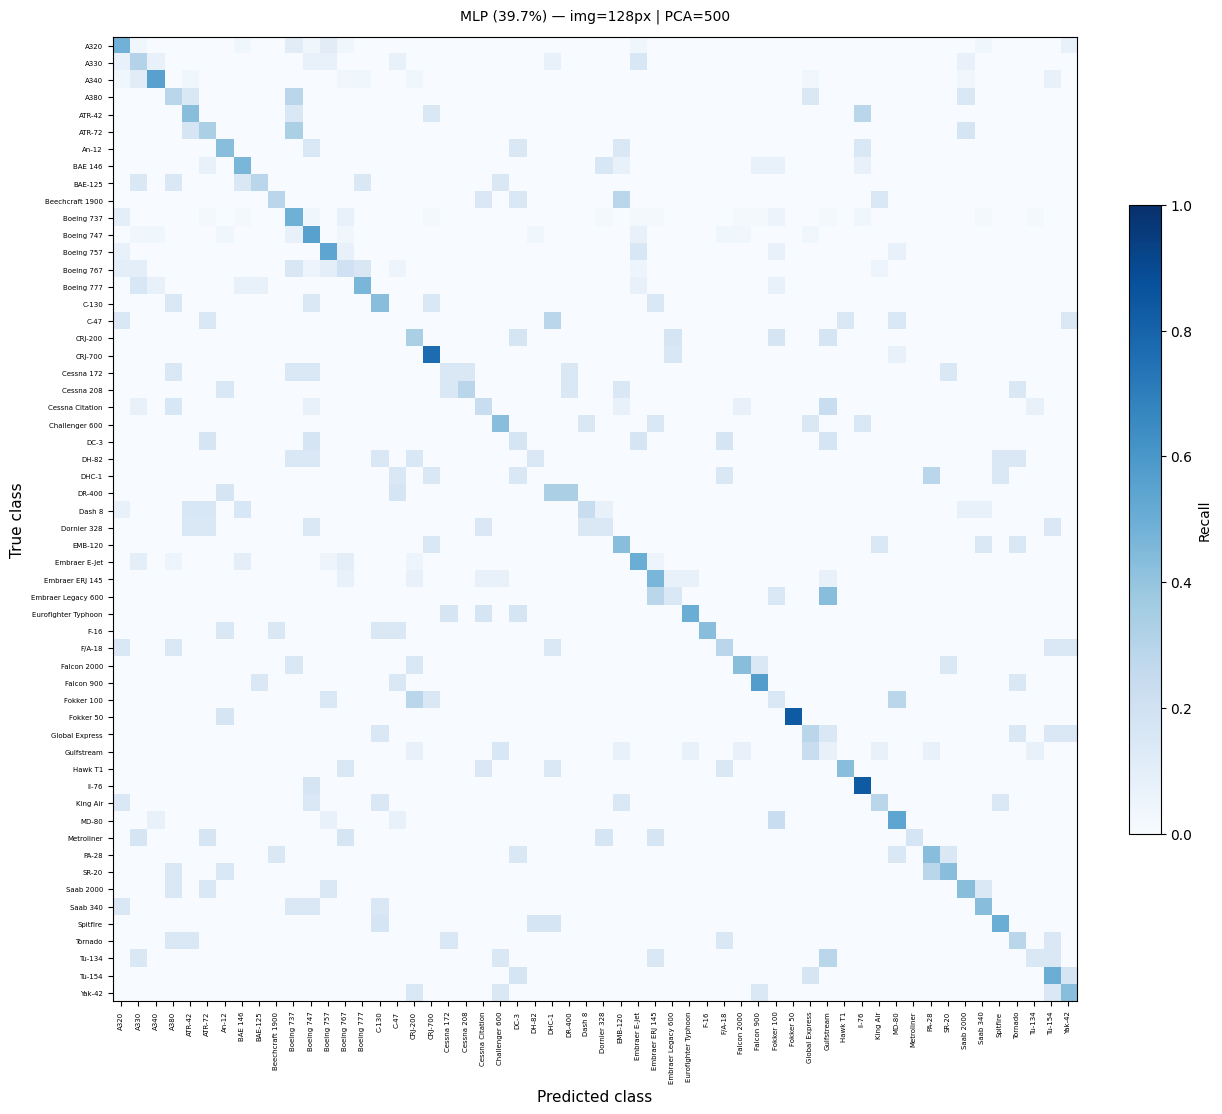

In [8]:
tag = f"img={IMG_SIZE}px | PCA={NUM_PCS}"

plot_confusion_matrix(
    results_mlp["cm"], classes,
    title=f"MLP ({results_mlp['accuracy']*100:.1f}%) — {tag}"
)

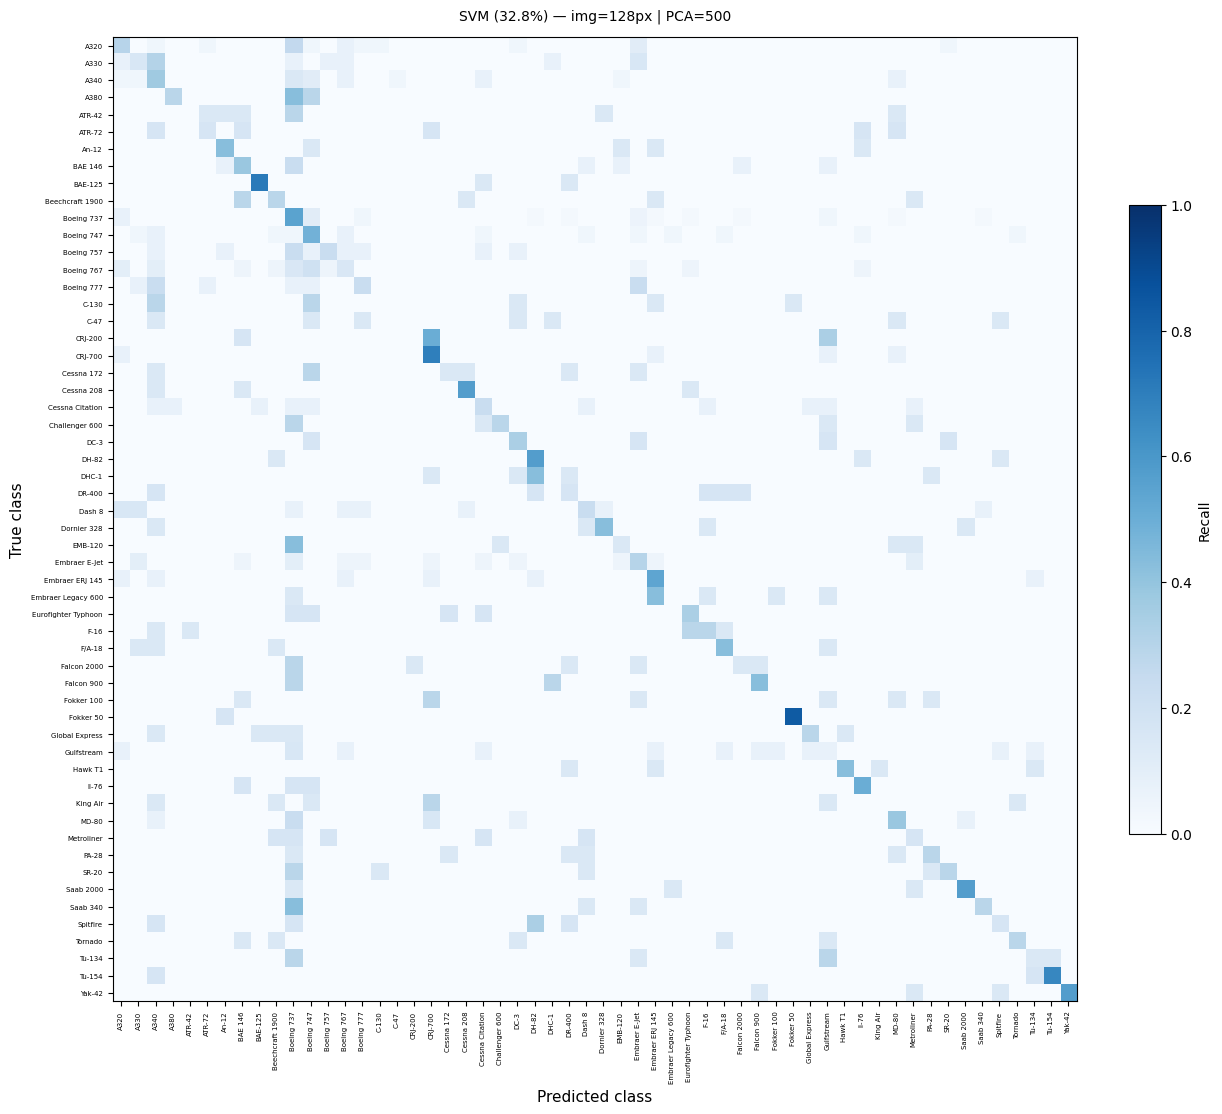

In [9]:
plot_confusion_matrix(
    results_svm["cm"], classes,
    title=f"SVM ({results_svm['accuracy']*100:.1f}%) — {tag}"
)

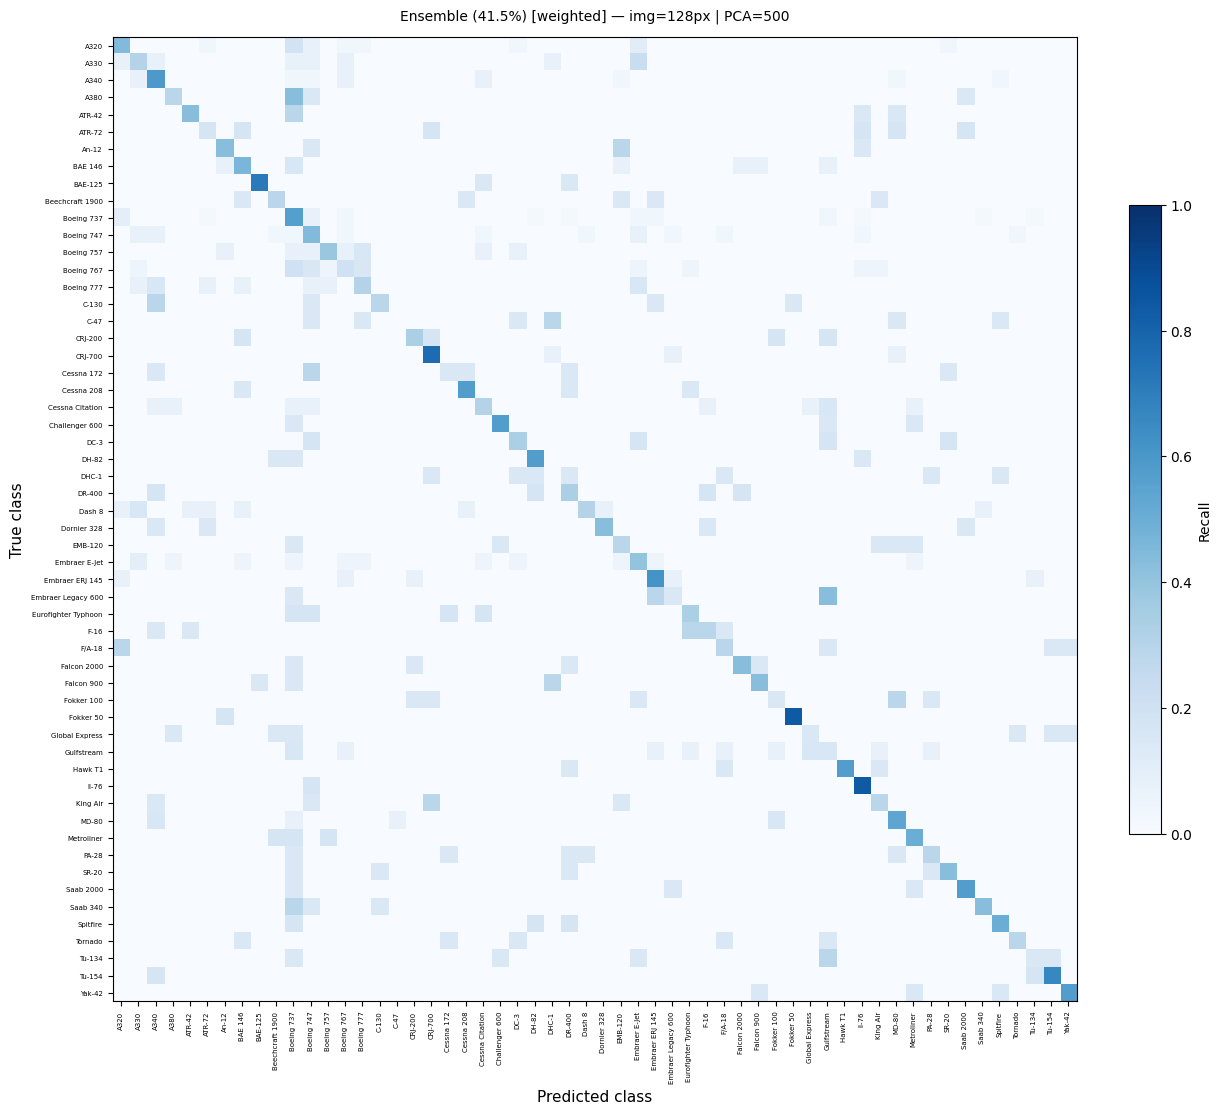

In [10]:
plot_confusion_matrix(
    results_ens["cm"], classes,
    title=f"Ensemble ({results_ens['accuracy']*100:.1f}%) [weighted] — {tag}"
)

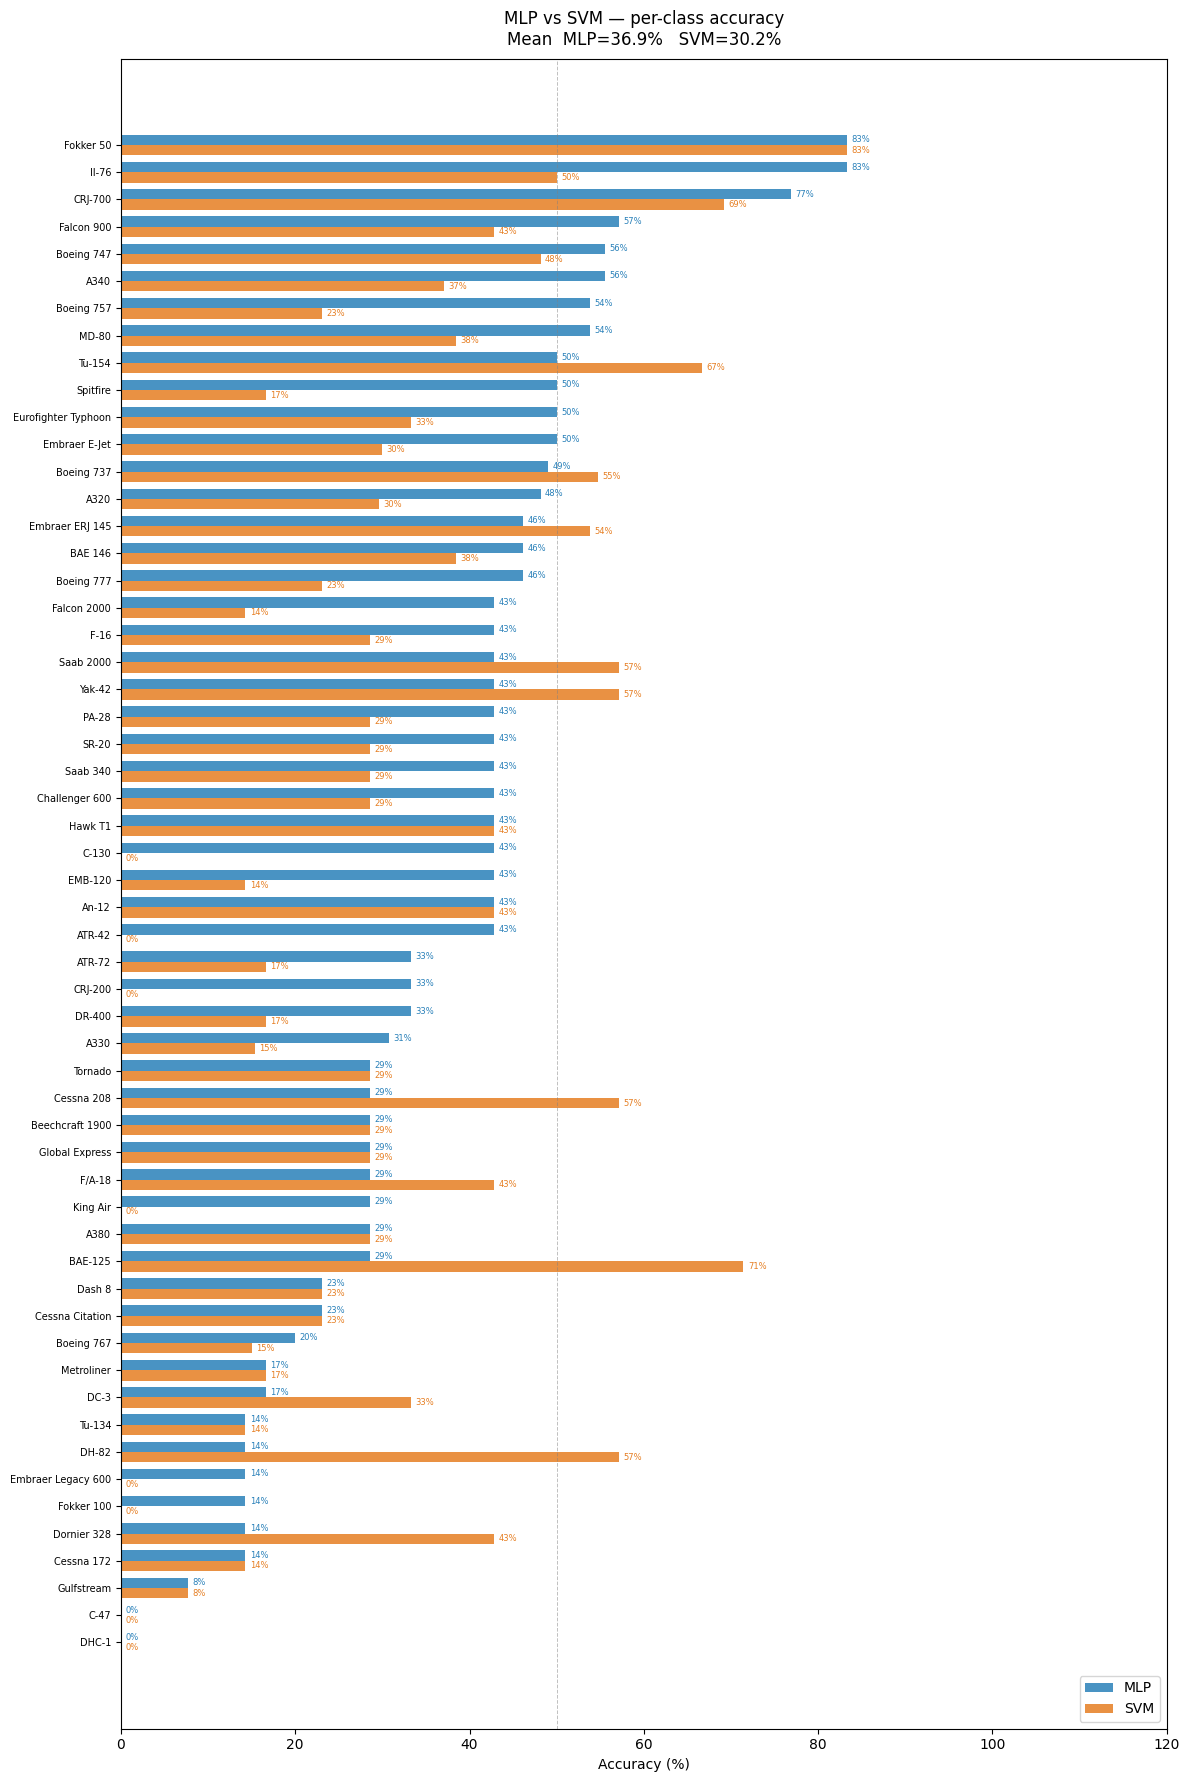

In [11]:
plot_comparison(results_mlp["cm"], results_svm["cm"], classes)

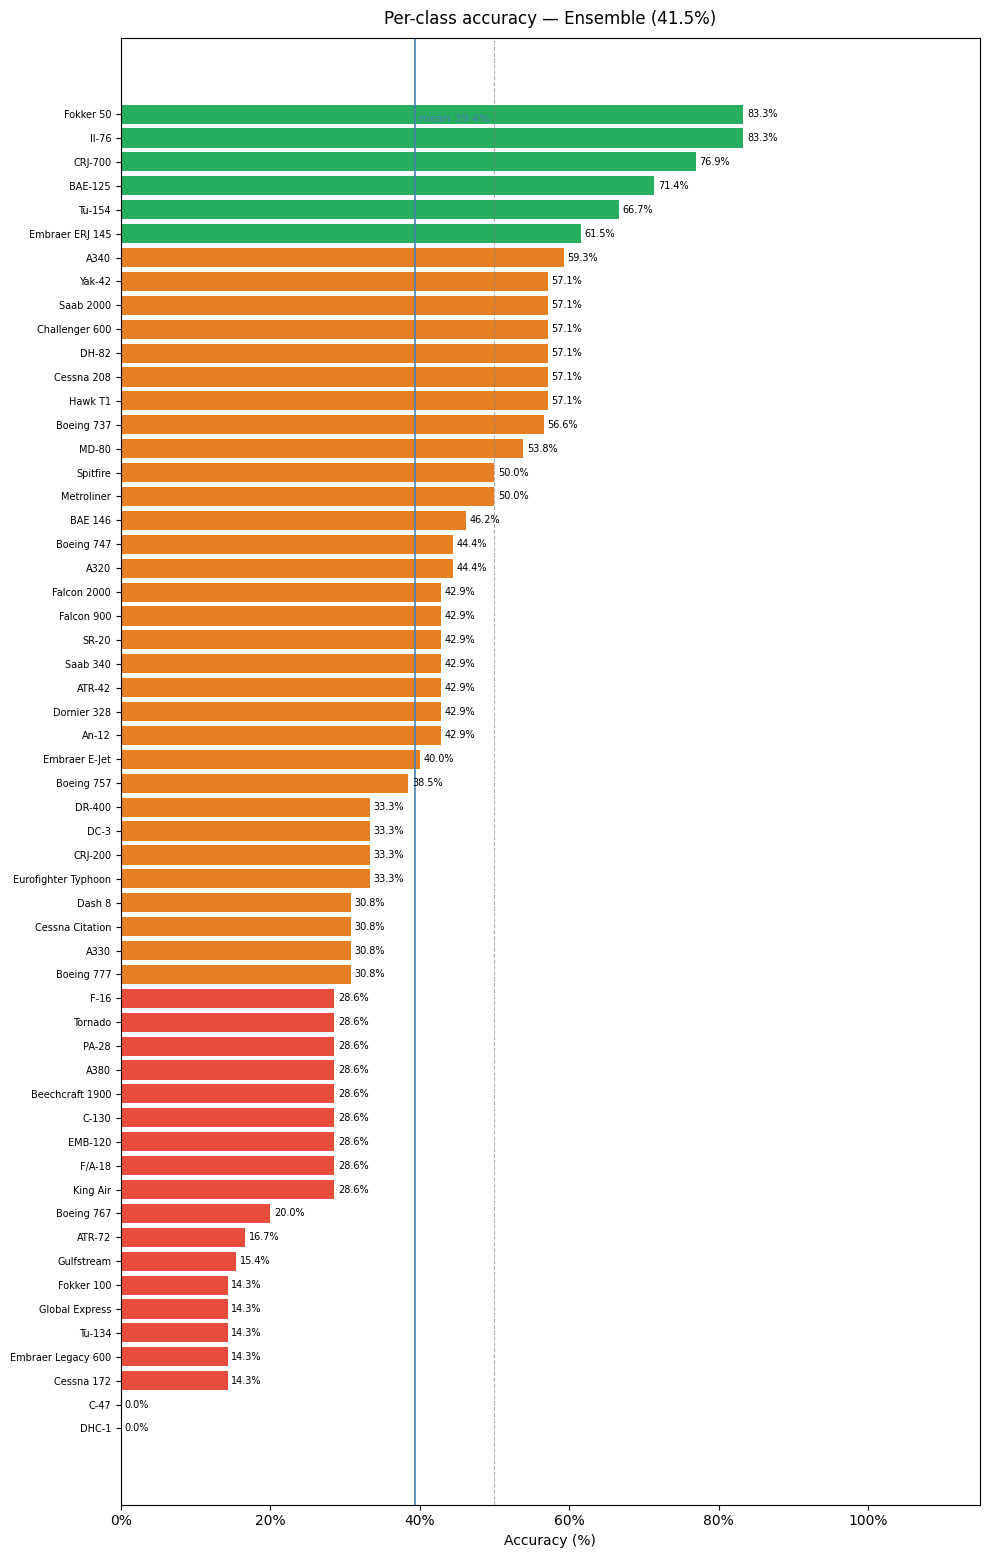

In [12]:
plot_per_class_accuracy(
    results_ens["cm"], classes,
    title=f"Per-class accuracy — Ensemble ({results_ens['accuracy']*100:.1f}%)"
)

## 9. Save of the models data in order to use them for interface.py

In [13]:
import joblib

joblib.dump({
    'data':        data,
    'mlp':         mlp,
    'svm':         svm,
    'CROP_BOTTOM': CROP_BOTTOM,
    'IMG_SIZE':    IMG_SIZE,
    'best_wmlp':   best_wmlp,
    'best_wsvm':   best_wsvm,
}, "model_aircraft.pkl")

print("Model saved to 'model_aircraft.pkl'")

Model saved to 'model_aircraft.pkl'
